# Modelos Supervisados: Clasificación y Regresión
## Dataset: San Francisco City Employee Salaries

**Curso:** Aprendizaje Automático — MIAR0525  
**Semana 2:** Continuación del pipeline — Fase de Modelado  
**Prerequisito:** Notebook Semana 1 (EDA y Preprocesamiento)

---

### Objetivos de aprendizaje

Al finalizar este notebook el estudiante será capaz de:

1. Reproducir el pipeline de preprocesamiento de la Semana 1 y partir de él para modelar
2. Formular un **problema de clasificación** (¿recibe overtime?) y uno de **regresión** (¿cuánto gana?)
3. Entrenar y comparar modelos: **Logistic Regression, Decision Tree, Random Forest, SVM**
4. Aplicar **validación cruzada** y entender por qué no basta con un único train/test split
5. Evaluar modelos con las métricas correctas para cada tipo de problema
6. Ajustar hiperparámetros con **GridSearchCV**
7. Interpretar **importancia de variables** y curvas ROC

---

### Flujo de trabajo — Semana 2

```
Preprocesamiento (S1) → Clasificación → Regresión → Evaluación → Hiperparámetros → Interpretación
```

---

>  **Nota importante:** Este notebook **continúa directamente** desde el punto donde terminó el notebook de la Semana 1. La Sección 0 reproduce de forma compacta todo el preprocesamiento necesario para que el entorno quede listo. Los estudiantes que ya ejecutaron el notebook anterior pueden saltar directamente a la **Sección 1**.


---
## 0. Reconstrucción del Pipeline (Semana 1)
Esta sección reproduce el preprocesamiento completo de forma compacta. **Ejecútala completa antes de continuar.**


In [13]:
# ── 0.1 Importaciones ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Configuración visual
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(' Librerías importadas.')


 Librerías importadas.


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# ── 0.2 Carga del dataset ──────────────────────────────────────────────────────
# Ruta compatible con la estructura del repositorio en GitHub y con Google Colab.
from pathlib import Path

possible_paths = [
    Path('../data/raw/Salarios_Cerveceria.csv'),  # cuando el notebook se ejecuta desde /notebooks
    Path('data/raw/Salarios_Cerveceria.csv'),     # cuando se ejecuta desde la raíz del repositorio
    Path('/content/drive/MyDrive/Salarios_Cerveceria.csv'),  # alternativa en Google Drive
]

dataset_path = next((p for p in possible_paths if p.exists()), None)

if dataset_path is None:
    raise FileNotFoundError(
        'No se encontró Salarios_Cerveceria.csv. Verifica que el archivo esté en data/raw/ o en Google Drive.'
    )

df = pd.read_csv(dataset_path, low_memory=False, encoding='latin1')
print(f'Dataset cargado desde: {dataset_path}')
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')


Dataset cargado: 40,544 filas × 14 columnas


In [16]:
# ── 0.3 Preprocesamiento compacto (replica Semana 1) ──────────────────────────

# 1. Conversión de columnas numéricas almacenadas como texto
for col in ['SalarioBase', 'HorasExtra', 'OtrosPagos', 'Beneficios']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Eliminar columnas irrelevantes
df.drop(columns=[c for c in ['Notas', 'TipoContrato', 'Oficina', 'Id'] if c in df.columns],
        inplace=True)

# 3. Imputar valores faltantes
df['SalarioBase']  = df['SalarioBase'].fillna(df['SalarioBase'].median())
df['Beneficios'] = df.groupby('Año')['Beneficios'].transform(lambda x: x.fillna(x.median()))

# 4. Eliminar registros con SalarioTotal negativo
df = df[df['SalarioTotal'] >= 0].copy()

# 5. Winsorización con IQR (variables de salario)
def winsorizacion_iqr(serie, factor=1.5):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return serie.clip(lower=Q1 - factor * IQR, upper=Q3 + factor * IQR)

cols_salario = ['SalarioBase', 'HorasExtra', 'OtrosPagos', 'Beneficios', 'SalarioTotal', 'SalarioTotalConBeneficios']
df_clean = df.copy()
for col in cols_salario:
    df_clean[col] = winsorizacion_iqr(df_clean[col])

# 6. Feature engineering
df_clean['OvertimeRatio']  = df_clean['HorasExtra'] / (df_clean['SalarioBase'] + 1)
df_clean['BeneficiosRatio']  = df_clean['Beneficios']    / (df_clean['SalarioTotal'] + 1)
df_clean['LogSalarioTotal']    = np.log1p(df_clean['SalarioTotal'])
df_clean['TieneOvertime']  = (df_clean['HorasExtra'] > 0).astype(int)

# 7. Codificación de Cargo (top 30 + 'Otro')
top_jobs = df_clean['Cargo'].value_counts().nlargest(30).index
df_clean['Cargo_Cat'] = df_clean['Cargo'].where(
    df_clean['Cargo'].isin(top_jobs), other='Otro')
le = LabelEncoder()
df_clean['Cargo_LabelEncoded'] = le.fit_transform(df_clean['Cargo_Cat'])

print(f' Preprocesamiento completado. Shape: {df_clean.shape}')
print(f'   Clases TieneOvertime: {df_clean["TieneOvertime"].value_counts().to_dict()}')


 Preprocesamiento completado. Shape: (40544, 17)
   Clases TieneOvertime: {1: 39767, 0: 777}


In [17]:
# ── 0.4 Definición de features y variable objetivo ────────────────────────────
# OvertimeRatio = HorasExtra / (SalarioBase + 1)
features_clf = ['SalarioBase', 'OtrosPagos', 'Beneficios', 'Año',
                 'BeneficiosRatio', 'LogSalarioTotal',
                'Cargo_LabelEncoded']

# ↑ OvertimeRatio removido

# Problema A — Clasificación: ¿El empleado recibe overtime?
X_clf = df_clean[features_clf].copy()
y_clf = df_clean['TieneOvertime'].copy()



#########################################
#************************************
#########################################
#SalarioTotal ≈ SalarioBase + HorasExtra + OtrosPagos
# Problema B — Regresión: ¿Cuánto gana el empleado en total?
features_reg = [ 'Beneficios', 'Año',
                 'BeneficiosRatio', 'Cargo_LabelEncoded']
# ↑ Fuera: SalarioBase, HorasExtra, OtrosPagos, OvertimeRatio, LogSalarioTotal

X_reg = df_clean[features_reg].copy()
y_reg = df_clean['SalarioTotal'].copy()

# División train/test (80/20 con estratificación en clasificación)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42)

# Escalado (fit SOLO en train — evitar data leakage)
scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print(' Datasets listos para modelado')
print(f'   Clasificación — Train: {X_train_c_sc.shape}  |  Test: {X_test_c_sc.shape}')
print(f'   Regresión     — Train: {X_train_r_sc.shape}  |  Test: {X_test_r_sc.shape}')
print(f'   Balance clases (train): {y_train_c.mean()*100:.1f}% con overtime')


 Datasets listos para modelado
   Clasificación — Train: (32435, 7)  |  Test: (8109, 7)
   Regresión     — Train: (32435, 4)  |  Test: (8109, 4)
   Balance clases (train): 98.1% con overtime


---
## 1. Fundamentos: ¿Clasificación o Regresión?

Antes de entrenar cualquier modelo, debemos **formular el problema correctamente**.

| Dimensión | Clasificación | Regresión |
|-----------|--------------|-----------|
| Variable objetivo | Categórica / discreta | Numérica / continua |
| Pregunta que responde | ¿A qué clase pertenece? | ¿Cuánto / cuán grande? |
| Ejemplo en este dataset | ¿Recibe overtime? (Sí/No) | ¿Cuál es el salario total? |
| Métricas principales | Accuracy, F1, AUC-ROC | MAE, RMSE, R² |

En este notebook trabajaremos **ambos problemas** con el mismo dataset, lo que nos permite ver cómo varía el proceso de modelado según el tipo de tarea.

---


---
## 2. Problema de Clasificación: Predicción de Overtime

**Variable objetivo:** `TieneOvertime` (0 = Sin overtime, 1 = Con overtime)  
**Tipo:** Clasificación binaria

### 2.1 Logistic Regression — Línea base


**¿Por qué empezar con Regresión Logística?**

A pesar del nombre, la Regresión Logística es un algoritmo de **clasificación**. Es el punto de partida ideal porque:
- Es interpretable: los coeficientes muestran el peso de cada variable
- Converge rápido, ideal para establecer una **línea base** (baseline)
- Asume relación lineal entre features y log-odds de la clase positiva

**Supuestos clave:**
- No requiere que los features sigan distribución normal, pero sí que sean linealmente separables
- Sensible a outliers y multicolinealidad
- Requiere escalado previo (ya aplicado)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

# Imputar NaN residuales (fit solo en train)
imputer = SimpleImputer(strategy='median')
X_train_c_sc = imputer.fit_transform(X_train_c_sc)
X_test_c_sc  = imputer.transform(X_test_c_sc)

# Entrenar modelo
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_c_sc, y_train_c)

# Predicciones
y_pred_lr  = lr.predict(X_test_c_sc)
y_prob_lr  = lr.predict_proba(X_test_c_sc)[:, 1]

# Métricas
print('='*50)
print('  LOGISTIC REGRESSION — Resultados en Test')
print('='*50)
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_lr):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_lr):.4f}') # TP / (TP + FP)
print(f'  Recall    : {recall_score(y_test_c, y_pred_lr):.4f}') # TP /  (TP + FN)
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_lr):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_lr):.4f}')
print()
print(classification_report(y_test_c, y_pred_lr,
      target_names=['Sin overtime', 'Con overtime']))

  LOGISTIC REGRESSION — Resultados en Test
  Accuracy  : 0.9805
  Precision : 0.9817
  Recall    : 0.9987
  F1-Score  : 0.9902
  AUC-ROC   : 0.9451

              precision    recall  f1-score   support

Sin overtime       0.41      0.05      0.08       155
Con overtime       0.98      1.00      0.99      7954

    accuracy                           0.98      8109
   macro avg       0.70      0.52      0.54      8109
weighted avg       0.97      0.98      0.97      8109



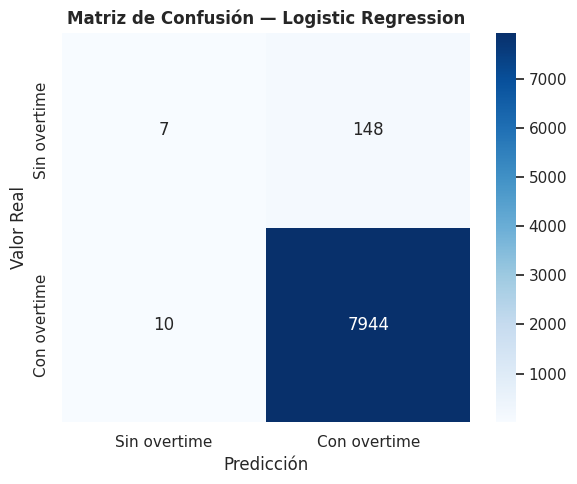

In [19]:
# Matriz de confusión — Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_c, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin overtime', 'Con overtime'],
            yticklabels=['Sin overtime', 'Con overtime'], ax=ax)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)
ax.set_title('Matriz de Confusión — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()


> **¿Cómo leer la matriz de confusión?**
>
> | | Pred: No | Pred: Sí |
> |---|---|---|
> | **Real: No** | Verdadero Negativo (TN) | Falso Positivo (FP) |
> | **Real: Sí** | Falso Negativo (FN) | Verdadero Positivo (TP) |
>
> - **Precision** = TP / (TP + FP): de los que predije "con overtime", ¿cuántos lo eran en realidad?  
> - **Recall** = TP / (TP + FN): de los que *realmente* tienen overtime, ¿cuántos capturé?  
> - **F1** = media armónica de Precision y Recall → equilibra ambas métricas  
> - **AUC-ROC**: capacidad del modelo para distinguir entre clases (1.0 = perfecto, 0.5 = aleatorio)


### 2.2 Decision Tree (Árbol de Decisión)


**¿Cómo funciona?**

Un árbol de decisión divide el espacio de features mediante **reglas if-then** aprendidas de los datos. En cada nodo elige la variable y el umbral que más reduce la **impureza** (Gini o Entropía).

**Ventajas:**
- Altamente interpretable (se puede visualizar)
- No requiere escalado
- Captura relaciones no lineales

**Desventaja principal: sobreajuste (overfitting)**  
Un árbol sin restricciones memoriza el conjunto de entrenamiento. El hiperparámetro `max_depth` es el control más importante.


In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Árbol sin restricción de profundidad (para ver el efecto del overfitting)
dt_sin_poda = DecisionTreeClassifier(random_state=42)
dt_sin_poda.fit(X_train_c_sc, y_train_c)

# Árbol con profundidad controlada
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, random_state=42)
dt.fit(X_train_c_sc, y_train_c)

# Comparación train vs test para detectar overfitting
print('Efecto del control de profundidad en overfitting:')
print()
print(f'{'Modelo':<25} {'Accuracy Train':>16} {'Accuracy Test':>15}')
print('-' * 58)

for nombre, modelo in [('Sin poda (sin límite)', dt_sin_poda),
                        ('Con poda (max_depth=6)', dt)]:
    acc_train = accuracy_score(y_train_c, modelo.predict(X_train_c_sc))
    acc_test  = accuracy_score(y_test_c,  modelo.predict(X_test_c_sc))
    gap = acc_train - acc_test
    print(f'{nombre:<25} {acc_train:>16.4f} {acc_test:>15.4f}  (gap: {gap:+.4f})')

print()
print('→ Un gap grande (train >> test) indica SOBREAJUSTE.')


Efecto del control de profundidad en overfitting:

Modelo                      Accuracy Train   Accuracy Test
----------------------------------------------------------
Sin poda (sin límite)               1.0000          0.9940  (gap: +0.0060)
Con poda (max_depth=6)              0.9808          0.9809  (gap: -0.0001)

→ Un gap grande (train >> test) indica SOBREAJUSTE.


In [21]:
# Métricas completas del árbol podado
y_pred_dt = dt.predict(X_test_c_sc)
y_prob_dt = dt.predict_proba(X_test_c_sc)[:, 1]

print('='*50)
print('  DECISION TREE (max_depth=6) — Resultados en Test')
print('='*50)
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_dt):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_dt):.4f}')
print(f'  Recall    : {recall_score(y_test_c, y_pred_dt):.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_dt):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_dt):.4f}')


  DECISION TREE (max_depth=6) — Resultados en Test
  Accuracy  : 0.9809
  Precision : 0.9809
  Recall    : 1.0000
  F1-Score  : 0.9904
  AUC-ROC   : 0.7952


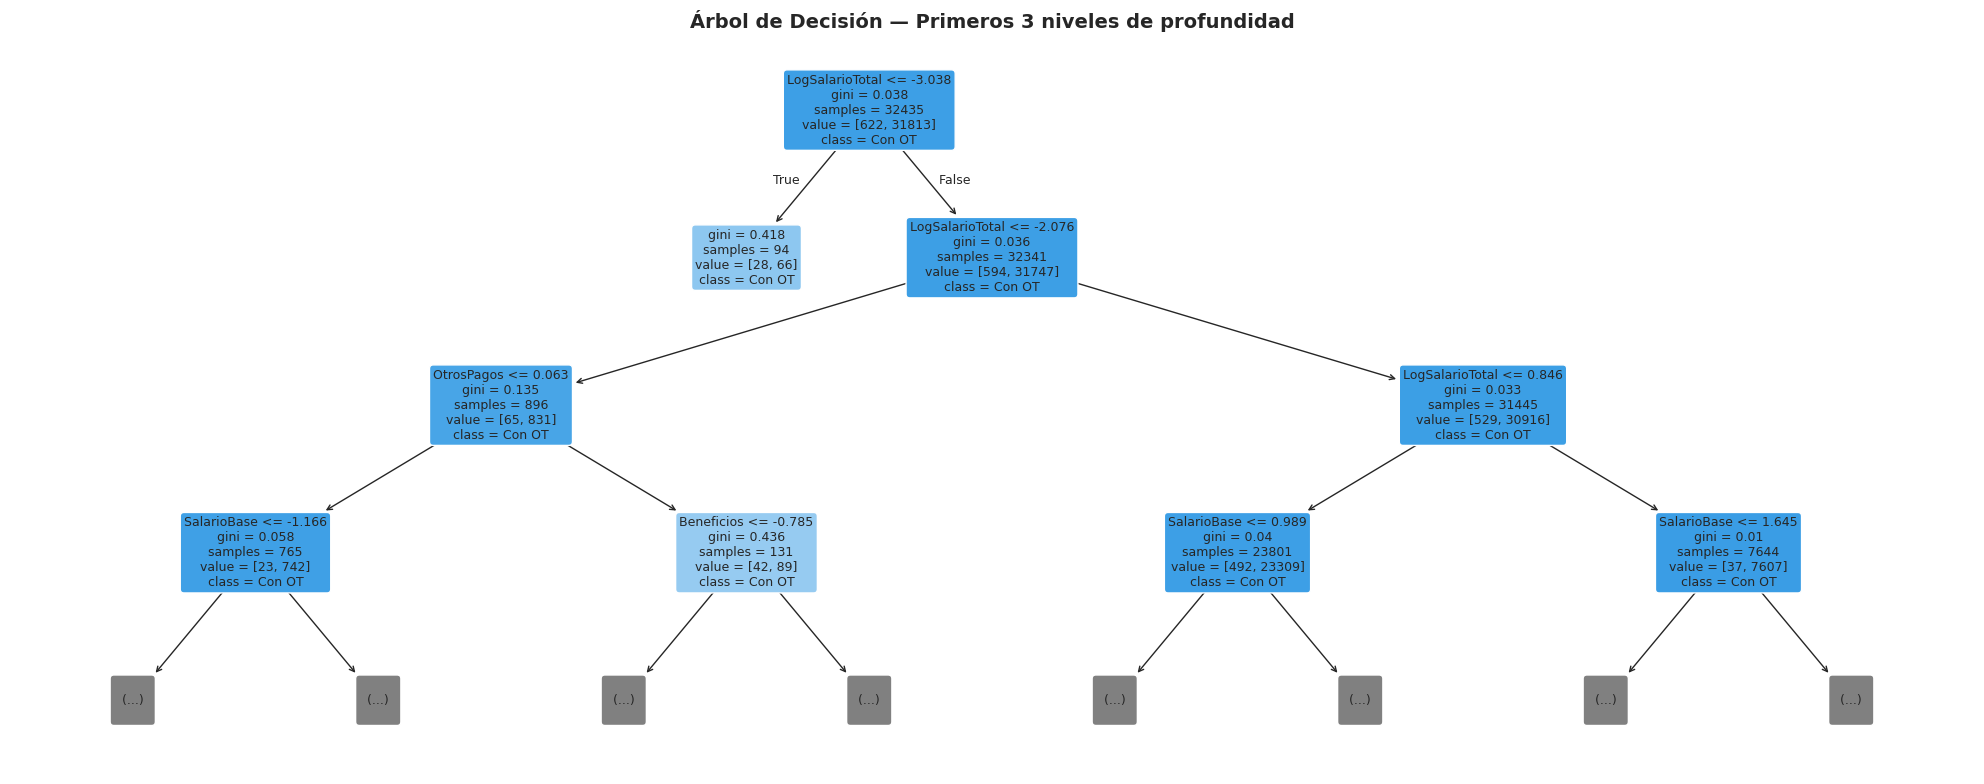

In [22]:
# Visualización del árbol (primeros 3 niveles)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3,
          feature_names=features_clf,
          class_names=['Sin OT', 'Con OT'],
          filled=True, rounded=True,
          fontsize=9, ax=ax)
ax.set_title('Árbol de Decisión — Primeros 3 niveles de profundidad',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.3 Random Forest

**¿Qué problema resuelve frente al árbol individual?**

Random Forest construye **múltiples árboles de decisión** sobre submuestras aleatorias del dataset y hace predicciones por **votación**. Esta técnica se llama **Bagging** (Bootstrap Aggregating).

El doble de aleatoriedad (muestras + subconjunto de features) reduce drásticamente el sobreajuste y mejora la generalización.

| | Árbol individual | Random Forest |
|---|---|---|
| Varianza | Alta | Baja |
| Sesgo | Bajo | Bajo |
| Interpretabilidad | Alta | Media |
| Velocidad | Muy rápido | Más lento |
| Robustez al ruido | Baja | Alta |


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,     # número de árboles
    max_depth=10,         # profundidad máxima por árbol
    min_samples_leaf=20,  # mínimo de muestras en hoja
    max_features='sqrt',  # nro de features consideradas en cada split
    random_state=42,
    n_jobs=-1             # usar todos los núcleos disponibles
)
rf.fit(X_train_c_sc, y_train_c)

y_pred_rf = rf.predict(X_test_c_sc)
y_prob_rf = rf.predict_proba(X_test_c_sc)[:, 1]

print('='*50)
print('  RANDOM FOREST — Resultados en Test')
print('='*50)
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_rf):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_rf):.4f}')
print(f'  Recall    : {recall_score(y_test_c, y_pred_rf):.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_rf):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_rf):.4f}')


  RANDOM FOREST — Resultados en Test
  Accuracy  : 0.9809
  Precision : 0.9809
  Recall    : 1.0000
  F1-Score  : 0.9904
  AUC-ROC   : 0.9629


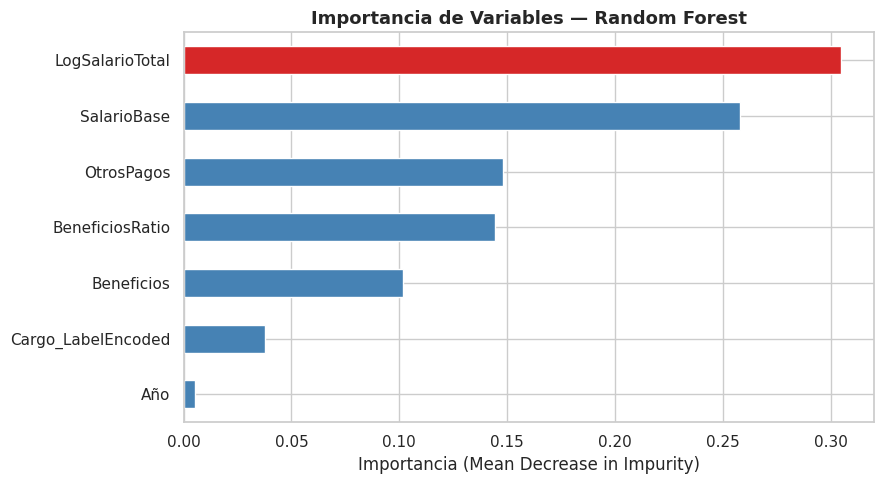


Top 3 variables más importantes:
  1. LogSalarioTotal: 0.3049
  2. SalarioBase: 0.2582
  3. OtrosPagos: 0.1481


In [24]:
# Importancia de variables — Random Forest
importancias = pd.Series(rf.feature_importances_, index=features_clf).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if v == importancias.max() else 'steelblue' for v in importancias]
importancias.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Importancia de Variables — Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

print('\nTop 3 variables más importantes:')
for i, (feat, val) in enumerate(importancias.sort_values(ascending=False).head(3).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')


### 2.4 Support Vector Machine (SVM)

**Idea central:**

SVM busca el **hiperplano** que maximiza el margen entre las clases. Los puntos más cercanos al hiperplano se llaman **vectores de soporte**.

Con el **kernel trick** (por ejemplo, `rbf`), SVM puede capturar fronteras de decisión no lineales proyectando los datos a espacios de mayor dimensión.

**¿Cuándo usar SVM?**
- Cuando el número de features es alto en relación a las muestras
- Cuando se necesita una frontera de decisión clara
- **Desventaja:** lento en datasets grandes; sensible a la escala (ya escalamos )

>  **SVM es computacionalmente costoso** con datasets grandes. Usaremos una muestra del 20% del conjunto de entrenamiento para este ejemplo.


In [25]:
from sklearn.svm import SVC

# Muestra para SVM (evitar tiempo de cómputo excesivo con >100k muestras)
sample_idx = np.random.RandomState(42).choice(len(X_train_c_sc),
                                               size=int(len(X_train_c_sc)*0.20),
                                               replace=False)
X_svm_train = X_train_c_sc[sample_idx]
y_svm_train = y_train_c.iloc[sample_idx]

svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          probability=True, random_state=42)
svm.fit(X_svm_train, y_svm_train)

y_pred_svm = svm.predict(X_test_c_sc)
y_prob_svm = svm.predict_proba(X_test_c_sc)[:, 1]

print('='*55)
print('  SVM (kernel=rbf, muestra 20%) — Resultados en Test')
print('='*55)
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_svm):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_svm):.4f}')
print(f'  Recall    : {recall_score(y_test_c, y_pred_svm):.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_svm):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_svm):.4f}')
print()
print(f'  (Entrenado con {len(X_svm_train):,} muestras de {len(X_train_c_sc):,})')


  SVM (kernel=rbf, muestra 20%) — Resultados en Test
  Accuracy  : 0.9809
  Precision : 0.9809
  Recall    : 1.0000
  F1-Score  : 0.9904
  AUC-ROC   : 0.9924

  (Entrenado con 6,487 muestras de 32,435)


### 2.5 Comparación de Modelos — Clasificación


In [26]:
# ── Tabla comparativa de métricas ──────────────────────────────────────────────
resultados_clf = {
    'Logistic Regression': {
        'pred': y_pred_lr, 'prob': y_prob_lr},
    'Decision Tree (d=6)': {
        'pred': y_pred_dt, 'prob': y_prob_dt},
    'Random Forest': {
        'pred': y_pred_rf, 'prob': y_prob_rf},
    'SVM (rbf, 20%)': {
        'pred': y_pred_svm, 'prob': y_prob_svm},
}

filas = []
for nombre, data in resultados_clf.items():
    filas.append({
        'Modelo': nombre,
        'Accuracy' : accuracy_score(y_test_c, data['pred']),
        'Precision': precision_score(y_test_c, data['pred']),
        'Recall'   : recall_score(y_test_c, data['pred']),
        'F1-Score' : f1_score(y_test_c, data['pred']),
        'AUC-ROC'  : roc_auc_score(y_test_c, data['prob'])
    })

df_comp = pd.DataFrame(filas).set_index('Modelo')
print('=== Comparación de Modelos de Clasificación ===')
print(df_comp.round(4).to_string())
print()
print(f'   Mejor F1-Score : {df_comp["F1-Score"].idxmax()}')
print(f'   Mejor AUC-ROC  : {df_comp["AUC-ROC"].idxmax()}')


=== Comparación de Modelos de Clasificación ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modelo                                                             
Logistic Regression    0.9805     0.9817  0.9987    0.9902   0.9451
Decision Tree (d=6)    0.9809     0.9809  1.0000    0.9904   0.7952
Random Forest          0.9809     0.9809  1.0000    0.9904   0.9629
SVM (rbf, 20%)         0.9809     0.9809  1.0000    0.9904   0.9924

   Mejor F1-Score : Decision Tree (d=6)
   Mejor AUC-ROC  : SVM (rbf, 20%)


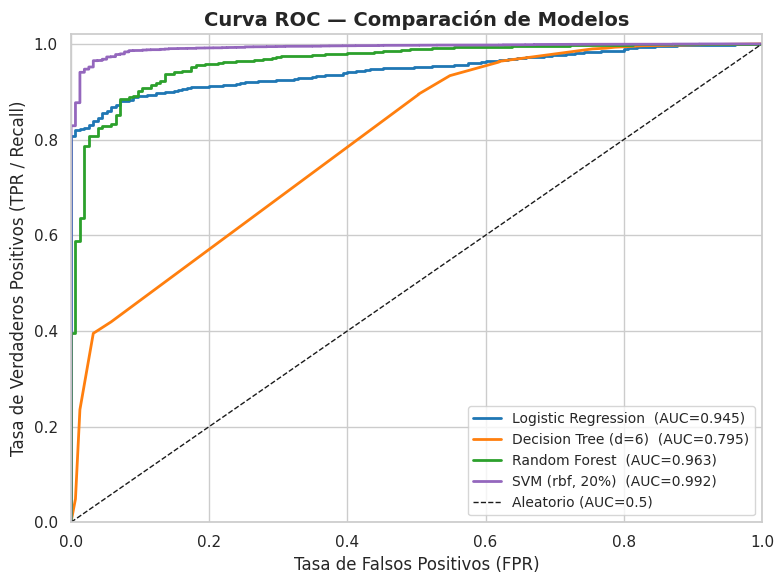

In [27]:
# ── Curva ROC comparativa ──────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

colores_modelos = {
    'Logistic Regression': '#1f77b4',
    'Decision Tree (d=6)': '#ff7f0e',
    'Random Forest':       '#2ca02c',
    'SVM (rbf, 20%)':      '#9467bd',
}

for nombre, data in resultados_clf.items():
    fpr, tpr, _ = roc_curve(y_test_c, data['prob'])
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{nombre}  (AUC={auc_val:.3f})',
            color=colores_modelos[nombre], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curva ROC — Comparación de Modelos', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


> **¿Cómo interpretar la curva ROC?**
>
> - Cada punto de la curva corresponde a un **umbral de decisión** diferente (normalmente 0.5 por defecto)
> - Cuanto más hacia la esquina superior izquierda, mejor el modelo
> - El **AUC** (Área Bajo la Curva) resume la calidad en todos los umbrales posibles:
>   - 1.0 = clasificador perfecto
>   - 0.5 = clasificador aleatorio (la línea diagonal)
> - AUC es especialmente útil cuando las **clases están desbalanceadas**


---
## 3. Validación Cruzada (Cross-Validation)

Un único train/test split puede ser **optimista o pesimista** dependiendo de qué muestras caen en cada conjunto. La validación cruzada **k-fold** repite el proceso k veces y promedia los resultados, obteniendo una estimación más robusta del desempeño.

```
┌───────┬───────┬───────┬───────┬───────┐
│ Fold 1│ Fold 2│ Fold 3│ Fold 4│ Fold 5│
├───────┼───────┼───────┼───────┼───────┤
│ TEST  │ TRAIN │ TRAIN │ TRAIN │ TRAIN │ → Iteración 1
│ TRAIN │ TEST  │ TRAIN │ TRAIN │ TRAIN │ → Iteración 2
│ TRAIN │ TRAIN │ TEST  │ TRAIN │ TRAIN │ → Iteración 3
│ TRAIN │ TRAIN │ TRAIN │ TEST  │ TRAIN │ → Iteración 4
│ TRAIN │ TRAIN │ TRAIN │ TRAIN │ TEST  │ → Iteración 5
└───────┴───────┴───────┴───────┴───────┘
         Promedio de las 5 métricas = estimación final
```

**Regla general:** Con datasets grandes, k=5 es suficiente. Con datasets pequeños, k=10.


In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Usamos StratifiedKFold para mantener el balance de clases en cada fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree (d=6)': DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   random_state=42, n_jobs=-1),
}

print('=== Validación Cruzada (5-fold, métrica: F1) ===')
print(f'{'Modelo':<25} {'Media F1':>10} {'Std F1':>10} {'Min':>8} {'Max':>8}')
print('-' * 65)

for nombre, modelo in modelos_cv.items():
    # cross_val_score entrena y evalúa automáticamente en cada fold
    scores = cross_val_score(modelo, X_train_c_sc, y_train_c,
                             cv=skf, scoring='f1', n_jobs=-1)
    print(f'{nombre:<25} {scores.mean():>10.4f} {scores.std():>10.4f} '
          f'{scores.min():>8.4f} {scores.max():>8.4f}')

print()
print('→ La Std indica variabilidad entre folds.')
print('→ Std alta puede indicar que el modelo es sensible a qué datos ve.')


=== Validación Cruzada (5-fold, métrica: F1) ===
Modelo                      Media F1     Std F1      Min      Max
-----------------------------------------------------------------
Logistic Regression           0.9900     0.0005   0.9894   0.9908
Decision Tree (d=6)           0.9903     0.0000   0.9903   0.9904
Random Forest                 0.9913     0.0003   0.9910   0.9917

→ La Std indica variabilidad entre folds.
→ Std alta puede indicar que el modelo es sensible a qué datos ve.


![image.png](ñocc5Q3gAAYcEkIYOAaI7CDgngDR0zpDWA+OmGEOkQjwlJaWkpCTYUUlJSUpKSnA5YQnjRjgAhHZOAFuPc4bwAAIOCSANHQJEdxBwTgBp6JwhrQfGTTGGSIX46NGjZ86cGexo5syZt912W3A5YQnjRjgAhHZOAFuPc4bwAAIOCSANHQJEdxBwTgBp6JwhrQfGTTGGSIV4SUmJ1+u9//77Dxw48B23qqqqBx54wOfzbd68WREg9lV8yviwZuzB64yIrUcnTfgCAVsEkIa2sKETCOgkgDTUSZPCF+OmiBypEDcMY82aNSkpKT6LpaSkrF27VuGdpIpPGUKchL22oNh6tKGEIxCwSwBpaJcc+oGANgJIQ20oiRwxborgUQhxwzAuXLiwc+fOYm47d+68cOGCwjVVFZ8yhDgVfj1xsfXo4QgvIOCAANLQATx0BQE9BJCGejjSeWHcFPGjE+IKR+6p4lOGEHfPgtgZCbYeO9TQBwS0EkAaasUJZyBghwDS0A41N/Vh3BQjilSIf/LJJ6tWrQp2tHr16pqamuBywhLGjXAACO2cALYe5wzhAQQcEkAaOgSI7iDgnADS0DlDWg+Mm2IMkQrxKVOmPP7448GO5s+fP3Xq1OBywhLGjXAACO2cALYe5wzhAQQcEkAaOgSI7iDgnADS0DlDWg+Mm2IMkQrx66+//q233gp2VFJSkpWVFVxOWMK4EQ4AoZ0TwNbjnCE8gIBDAkhDhwDRHQScE0AaOmdI64FxU4whUiGenp7+xhtvBDt644030tLSgssJSxg3wgEgtHMC2HqcM4QHEHBIAGnoECC6g4BzAkhD5wxpPTBuijFEKsQnTZp0zz33BDjq6em5++67J0yYEFBO+5Jxox0DojskgK3HIUB0BwHnBJCGzhnCAwg4JIA0dAiQvDvjphhGpEL8/fff93q9RUVFJ06cuMbt+PHjRUVFPp9v+/btigCxr+JTxremxB68zojYenTShC8QsEUAaWgLGzqBgE4CSEOdNCl8MW6KyJEKccMw1q5dm5SU5PP5krn5fL6kpKQXX3xR4Z2kik8ZQpyEvbag2Hq0oYQjELBLAGlolxz6gYA2AkhDbSiJHDFuiuBRCHHDML755pvXXnvtaW6vv/76N998o3AdXNXY2Dh9+vT09PQhQ4asWLGis7MzuE1AyYYNGzwez6xZswLKFS8ZN0UDVLmfALYe968RRpjwBJCGCb/EmKD7CSAN3b9G6hEyboo20QlxhaNeq3744Yfc3NwpU6ZUVVW99957mZmZixcvVvc6d+7coEGDcnJyIMTVoBKvFltP4q0pZhR3BJCGcbdkGHDiEUAaxvuaMm6KWdgR4o2NjS+99NLTTz+9adOmtrY2hXdr1fr16zMyMlpaWkThli1bkpKSmpqarG0Czp944oknn3yysLAQQjyATMK/xNaT8EuMCbqfANLQ/WuEESY8AaRhvC8x46aYRS9C/K233srPz79w4YJ0sXfv3pSUFK9pI0eOtNbKZsEnBQUFc+bMkeWXLl3yer2lpaWyJOCktrZ2wIABZ8+ehRAPINMfXmLr6Q+rjDm6nADS0OULhOH1BwJIw3hfZcZNMYtehPiMGTPuu+8+2f/atWs5OTnp6enbt2//4osvXn311eTk5KVLl8oGipPs7OyVK1daGwwdOjSgRNZ2dXWNGzeuuLjYMAwIcYml/5xg6+k/a42ZupYA0tC1S4OB9R8CSMN4X2vGTTGLXoT4DTfcsHbtWtm/urra6/WuXr1alsybNy8/P1++VJwkJycLYS3bjB49euHChfKl9eTNN9+8+eabxac5bQjx+vr6dlg8E2hubq6rq2tubo7nSWDsIBDfBJCG8b1+GH1CEEAaxvsy1tfXM6b6Kr9ehHhqaup7770nJfLKlSt9Pt/f//53WVJSUpKamipfKk4iF+LNzc2DBg3au3ev8GZDiNfBQAAEQAAEQAAEQAAEQICagCMhnpeXt27dOimv77rrroyMjGvXrsmSrVu3Dhw4UL5UnGRnZ7/wwgvWBuEeTVm0aNGUKVMumXb33XfPnDnz0qVL1rhWPwHnjDHcEY/3vyBxDyDeVxDjTwACSMMEWERMId4JIA3jfQWd3hEvKirKz88XX43yxRdfJCcnFxUVWYXv8uXLb7vtNmtJuPOCgoK5c+fK2tbW1nAf1iwsLPSEsv3798vuihPGTdEAVe4ngKfi3L9GGGHCE0AaJvwSY4LuJ4A0dP8aqUfIuCna9PJoyokTJ1JSUoYMGTJt2rTMzEy/3299LsUwjBEjRvzxj39UBJBV4usLL126JEq2bt0a7usLGxoaDlls3LhxkydPPnTokPzqQ+kz5AnjFrIKhfFCAFtPvKwUxpnABJCGCby4mFq8EEAaxstKhRsn4xau1jCMXoS4YRiffvrpAw88MGrUqJkzZ37yySdWX4cOHRozZsyBAwesheHOxQ/6FBYWHjhwYNu2bYMGDbL+oM+0adNGjhwZsq+NZ8TVj+OEjIJCVxHA1uOq5cBg+icBpGH/XHfM2lUEkIauWg4bg2HcFB17F+KKztFWNTY23nvvvWlpaTk5OcuXL7f+xH1hYWFeXl5IhxDiIbEkdiG2nsReX8wuLgggDeNimTDIxCaANIz39WXcFLOwI8SvXr165MiR1tZWhV/CKj5l1TfFEI4NoSMkgK0nQlBoBgJ9RwBp2Hds4RkEIiSANIwQlGubMW6K4dkR4ufPn/f5fDU1NQq/hFV8yhDihCugITS2Hg0Q4QIEnBFAGjrjh94goIEA0lADRFIXjJtiCDaFuNfrhRBXYEWVQwLYehwCRHcQcE4AaeicITyAgEMCSEOHAMm7M26KYdgU4rgjrmCKKucEsPU4ZwgPIOCQANLQIUB0BwHnBJCGzhnSemDcFGOwKcRxR1zBFFXOCWDrcc4QHkDAIQGkoUOA6A4CzgkgDZ0zpPXAuCnGYEeId3d3nz592vqdJ4oAsa/iU8Yz4rEHrzMith6dNOELBGwRQBrawoZOIKCTANJQJ00KX4ybIrIdIa5w54YqPmUIcTcshf0xYOuxzw49QUATAaShJpBwAwL2CSAN7bNzR0/GTTEWp0K8oqJiwYIFigCxr+JThhCPPXidEbH16KQJXyBgiwDS0BY2dAIBnQSQhjppUvhi3BSRnQrxV155xefzKQLEvopPGUI89uB1RsTWo5MmfIGALQJIQ1vY0AkEdBJAGuqkSeGLcVNEhhBXwEEVGQFsPWToERgETAJIQ5MEjiBARgBpSIZeU2DGTeGsFyF+U2+WlZWFO+IKvqiyRwBbjz1u6AUCGgkgDTXChCsQsEcAaWiPm3t6MW6K8fQixJOSkm688cbZ4W3UqFEQ4gq+qLJHAFuPPW7oBQIaCSANNcKEKxCwRwBpaI+be3oxborx9CLEx4wZc8899yj64xlxBRxU2SaArcc2OnQEAV0EkIa6SMIPCNgmgDS0jc4lHRk3xWB6EeJ/+MMf0tPTu7q6wrmAEA9HBuVOCGDrcUIPfUFACwGkoRaMcAICTgggDZ3Qc0Nfxk0xkl6EeHV19YIFC86dOxfOxYkTJ7Zv3x6ulqSccSMJjaC6CGDr0UUSfkDANgGkoW106AgCugggDXWRpPLDuCmi9yLEFT1dW8WnjK8vdO36RDQwbD0RYUIjEOhLAkjDvqQL3yAQEQGkYUSYXNyIcVMMEEJcAQdVZASw9ZChR2AQMAkgDU0SOIIAGQGkIRl6TYEZN4WzXoT4qlWrjh8/rujvwio+ZdwRd+HKRDEkbD1RwEJTEOgbAkjDvuEKryAQBQGkYRSwXNmUcVMMrRch7vV6P/jgA9H/4sWLPp+vpqZG4c4NVYybG0aCMdgmgK3HNjp0BAFdBJCGukjCDwjYJoA0tI3OJR0ZN8VgohPiXq8XQlxBE1W6CGDr0UUSfkDANgGkoW106AgCugggDXWRpPLDuCmiQ4gr4KCKjAC2HjL0CAwCJgGkoUkCRxAgI4A0JEOvKTDjpnAGIa6AgyoyAth6yNAjMAiYBJCGJgkcQYCMANKQDL2mwIybwlnvQnzdunXHuB08eNDr9b7zzjvipfX/igCxr+JTxoc1Yw9eZ0RsPTppwhcI2CKANLSFDZ1AQCcBpKFOmhS+GDdF5N6FuM9iXq/X8uq/T0WJIkDsq/iUIcRjD15nRGw9OmnCFwjYIoA0tIUNnUBAJwGkoU6aFL4YN0XkXoT49shMESD2VXzKEOKxB68zIrYenTThCwRsEUAa2sKGTiCgkwDSUCdNCl+MmyJyL0Jc0dO1VXzKEOKuXZ+IBoatJyJMaAQCfUkAadiXdOEbBCIigDSMCJOLGzFuigFCiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIv1lQRAAAgAElEQVQzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZxBiCvgoIqMALYeMvQIDAImAaShSQJHECAjgDQkQ68pMOOmcAYhroCDKjIC2HrI0CMwCJgEkIYmCRxBgIwA0pAMvabAjJvCGYS4Ag6qyAhg6yFDj8AgYBJAGpokcAQBMgJIQzL0mgIzbgpnEOIKOKgiI4Cthww9AoOASQBpaJLAEQTICCANydBrCsy4KZzFVIg3NjZOnz49PT19yJAhK1as6OzsDDmys2fPrlixYty4cRkZGTfccMO8efNOnz4dsmXIQsYtZBUK44UAtp54WSmMM4EJIA0TeHExtXghgDSMl5UKN07GLVytYRixE+I//PBDbm7ulClTqqqq3nvvvczMzMWLF4ccWUVFxciRI9etW1dTU1NWVjZmzJicnJwLFy6EbBxcyLgFl6Mkjghg64mjxcJQE5UA0jBRVxbziiMCSMM4WqyQQ2XcQlaJwtgJ8fXr12dkZLS0tIjAW7ZsSUpKampqCh7cpUuXrl27Jsu///57r9f7+uuvyxL1CeOmboNalxPA1uPyBcLw+gMBpGF/WGXM0eUEkIYuX6Beh8e4KZrFTogXFBTMmTNHDuXSpUter7e0tFSWKE5ycnKWLVumaGCtYtysJTiPOwLYeuJuyTDgxCOANEy8NcWM4o4A0jDulixgwIxbQKH1ZeyEeHZ29sqVK62xhw4dGlBirZXn//jHPzwez9atW2WJ+oRxU7dBrcsJYOtx+QJheP2BANKwP6wy5uhyAkhDly9Qr8Nj3BTNYifEk5OTi4uLrUMZPXr0woULrSXB5z09PTNnzhw6dGh7e3twbcgSxlh9fX07LJ4JNDc319XVNTc3x/MkMHYQiG8CSMP4Xj+MPiEIIA3jfRnr6+sZYyH1qih0uxB/8cUXk5OTa2pqFHMIqGKM/f/tnftbFEf2//+bHmQuDIgTEAIOQUXBKCriEsRb8iRBMT6i4oomMSaKCBgxnyg+RrwlERSNtzWCKAKCqIh21stm0V3vl8QLoKt4ob9+u56qpzMwJTEtZwbe55eqqao5p/rVc06frqnpOQkBARAAARAAARAAARAAAWoCvpKIh4WF5eXlGZPmV25NKSkpURRl27Ztxne9so4VcX+/fXz06BHWAHrBScQh+DsBuKG/n0HMvxcQgBv6+0n0oRXxlJSU9PR0kUa3trbKf6xZXl7er1+/b775RrylmxVVl24OxjDfJIBdcb55XjCrPkUAbtinTjcO1jcJwA1987x0f1aqLpLxPbc1hT2+sKWlhc2mtLTU2+MLNU07duyYzWb79NNPJVP31qXq4q0X7X5BAKHHL04TJtm7CcANe/f5xdH5BQG4oV+cJskkVV0kA3ouEWd/6JOamlpTU7N9+/bQ0FDjH/qkpaXFxsayiTY3N/fv3z8hIaGxsbGJy+XLlyWHYexSdTG2oO53BBB6/O6UYcK9jwDcsPedUxyR3xGAG/rdKfOYsKqLR6PxZc8l4pqmNTc3T5w40eFwhIeH5+TkGP/iPjU11e12s5mVlZUpnSQrK8s4b0ld1UUyAF2+TwChx/fPEWbY6wnADXv9KcYB+j4BuKHvnyP5DFVdJGN6NBGXzMPELv2QZU+KMdEWVL0hAgg9bwgs1IJA9wnADbvPCiNB4A0RgBu+IbA9plbVRWIOibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kypCIS+Cgi4wAQg8ZehgGAU4AbshJoAQBMgJwQzL0JhlWdZEoQyIugYMuMgIIPWToYRgEOAG4ISeBEgTICMANydCbZFjVRaIMibgEDrrICCD0kKGHYRDgBOCGnARKECAjADckQ2+SYVUXiTIk4hI46CIjgNBDhh6GQYATgBtyEihBgIwA3JAMvUmGVV0kyno0EW9ubp40aVJQUNDAgQOXLVvW3t7ubWYdHR1FRUXR0dF2u33cuHFNTU3eRnZuV3Xp3I4WPyKA0ONHJwtT7a0E4Ia99cziuPyIANzQj05Wl1NVdemyizX2XCL+4MGDiIiI9957r7q6etu2bf3791+0aJG3mRUVFVmt1uLi4rq6umnTpgUHB1+5csXbYI92VRePRrz0LwIIPf51vjDbXkkAbtgrTysOyr8IwA3963x1nq2qS+d20dJzifiaNWucTuf9+/eZ7a1bt/br1+/WrVtiKqLy5MmTkJCQ/Px81tLe3u52uz/77DMxQF5RdZGPQa+PE0Do8fEThOn1BQJww75wlnGMPk4AbujjJ+iV01N1kQzruUQ8JSXl448/FlNpaWmxWCxlZWWiRVTq6uoURTl37pxoWbJkyctcXLyUV1Rd5GPQ6+MEEHp8/ARhen2BANywL5xlHKOPE4Ab+vgJeuX0VF0kw3ouEQ8LC1u+fLlxKpGRkR4trHfLli2Kojx58kQMLikpsVgsjx8/Fi2SiqqLZAC6fJ8AQo/vnyPMsNcTgBv2+lOMA/R9AnBD3z9H8hmqukjG9FwiHhgYWFRUZJxKfHz8ggULjC2s/u2339psNmP7/v37FUXpch+LcRirNzY2njx58gzEnwmcPn365MmTp0+f9ueDwNxBwL8JwA39+/xh9r2CANzQ30/jyZMnGxsbOyeroqUXJuKnTp1qbGxUISAAAiAAAiAAAiAAAiBAR6CxsfHUqVOad+m5RDwsLCwvL884kze0NcVoAnUQAAEQAAEQAAEQAAEQ8E0CPZeIp6SkpKenCwqtra3yH2ueP39eDF66dGn3f6wp3oUKCIAACIAACIAACIAACPgsgZ5LxNnjC1taWhiL0tJS+eMLCwoK2MinT5/+qccX+ixrTAwEQAAEQAAEQAAEQAAEBIGeS8TZH/qkpqbW1NRs3749NDTU+Ic+aWlpsbGxYlpFRUU2m23Dhg11dXUZGRl/6g99hBJUQAAEQAAEQAAEQAAEQMBnCfRcIq5pWnNz88SJEx0OR3h4eE5OjvEv7lNTU42bTzo6OtasWRMVFWWz2ZKSkuT73H0WLiYGAiAAAiAAAiAAAiAAAt4I9Ggi7m0SaAcBEAABEAABEAABEACBvkYAiXhfO+M4XhAAARAAARAAARAAAZ8ggETcJ04DJgECIAACIAACIAACINDXCCAR72tnHMcLAiAAAiAAAiAAAiDgEwSQiPvEacAkQAAEQAAEQAAEQAAE+hoBJOJ97YzjeEEABEAABEAABEAABHyCABJxnzgNmAQIgAAIgAAIgAAIgEBfI4BE3L/PeGFhodPpNPEYjh07piiKqqpynYWFhY2NjcYxiqKsW7fO2PLKOrOl6BIUFJSQkLBhw4bnz5+/8o20A7KysuLj42nnAOsgAAIgAAJ/hUBhYSG7+iiK4nK5xo8fX1VV9VcUenvvu+++m5WV5a3XlPaysjJxLKxibmIgmeS5c+cKCwv/97//ScagS04Aibicj6/3mp6It7W1NTU1PXr0SH7kndPupqam27dvy9/l0csS8bKysqampurq6lmzZimKUlRU5DHM115evnz5/PnzvjYrzIeEgLiWWyyWkJCQhISERYsWNTc3//XJuN1u438Pd6nQ9HtCt9vtcTkXLwsLC7ucgymNGRkZOTk5XapqaWlRFKWsrKzLXknjrVu35s6d+9Zbb9nt9ri4uF27drHBu3btiouL8/0bfsmhocsUAoWFhQ6Ho0mXAwcOJCYmBgQEeCwwmWKoxxLx6upqdjhNTU1nzpwxZfKvVMLuAe7evfvKkRjgjQAScW9k/KPd9ES8m4fdORHv5huNwzxW31+8eBEXFzdkyBDjmL9ef/z48V9XAg0g0CUB47W8trZ2/fr1Q4cOtVqtP/30U5fju9949uzZq1evysebfk949uxZcSGPiIjIyMgQL2/evCmfzGv3/vOf/7TZbLdu3epSw+sl4rdv346Ojp40aVJ5eXldXd3GjRu3bdvG9D9//jwmJmb79u1dmkNj3yHgcfW8deuWxWJZuHCh6QR6LBH/K9lwe3v7ixcvXuPYkYi/BjSPtyAR9wDiZy89Qolx9hcuXJgyZUpQUFBISEhGRsb169dFb2tra2ZmptPpDAsLy8/P/+677xRFYb0eyfG2bduGDx9ut9vZN3fsJlsskrHKsWPHNE3zSM0PHz6cnJzscDhCQ0NTU1PPnj0rrIuKhy1N0z755BO73S4G3Lx5MzMz0+Vy2e32lJSUX375RXS1t7cvXrx4wIAB/fv3X7hw4e7duxVFYYnL1atX2RJadna2y+VKSEjQNK29vT0/P3/QoEFWqzUuLm737t1C1a+//vr++++7XC6HwzFkyJC1a9eyLm/tHsuQEs6Koqxdu7awsDA8PNzlcs2bN++VXzWIWaHiFwQ6O+CTJ0/S0tKsVuuVK1f84hC8TVKyJG/uze3cuXM/+ugjb9N4vUR89uzZycnJ3pa9V61aNXLkSG8W0d5HCHR23vDw8KlTp7LDv3379rx582JiYux2++DBg/Pz89vb2wUZeWxvbGxMTEy02Wzx8fFVVVUeifiBAwfeffddm80WERGxZMmSJ0+eMLXsglhdXT1jxgyn0xkdHc2uUxs3boyOjh4wYMD8+fONcxCT0TRNkg1fu3YtIyMjJCQkKChoypQpFy5cEG9kPr527dpBgwZZLBaWx5eVlSUkJNhstsjIyIKCAuFELS0t2dnZkZGRNpstKipq5syZwq5ICdxut1COSvcJIBHvPitfHNk5lLBZ3rhxIzQ0NDExsby8fM+ePTExMW63u62tjfVOmzatf//+33//fVVVVXp6enR0dJeJ+PHjxxVFycnJqa+vP3z48MqVK2trazVNa2pqUhRl8eLFbLWMqTUm4vv27bNYLOnp6RUVFVVVVQUFBYcOHeqMr3MinpSUNGzYMDbywYMHbrc7Pj5+z549VVVVU6dODQkJ+f3331nvkiVLrFZrUVFRdXV1dnY2OwRjIh4RETF//vyampojR45omvbRRx+5XK6NGzfW1tZ+9dVXFotFbAeMiYkZN25cRUVFfX19SUnJypUrmQlv7cZEXM5ZUZTo6OhZs2YdOXLk5Zqc1Wpdvnx5Zw5o8V8CXTrgv//9b0VR8vPzxXF5u7a9/GTeunVrzpw54eHhdrt96NChGzZsYO8y5sEk94TGCbDL/KlTpyZNmhQUFMT2zEjuk9kVusvLuWDCKo8ePXI6nTt37jS2l5SUuN1uh8ORlpamquqf3ZrS1tZmtVrFXhSjZlZvbm5WFAUbzDqT6VMtHs778OHDwMDAzz77jEG4cOFCTk5ORUVFQ0NDSUlJZGTkvHnzBB9JbL9z547T6UxOTj548OCOHTvcbvdbb70l9ogfPHjQYrGwi0JxcbHD4cjIyGBq2QUxJiZm1apVtbW1M2bMCAgIyM3N/eCDD6qqqjZv3my1WlevXi3mYKwwD/3tt9+eceno6NA0ra2tze12v/POO3v27CkvL09MTAwNDb1x4wZ7r9vtjoiISElJqaioqKysfPz48fr16/v165eTk1NbW7tx40an0ymuWfPmzYuIiNixY0dDQ8PevXvnzp2radrdu3dXrFihKArbFdPliptxnqh3SQCJeJdY/KbRI5SIeS9ZssTpdN6/f5+1NDc3WyyWTZs2aZrGsgRx5Xvx4sWQIUO6TMTXrVvncrmETmPFmHazdtHS0dERFRU1ZcoU4/gu6yzunD59+tmzZ/fu3Vu3bp3FYtm3bx8bvHLlyv79+4vMu729fdCgQcuWLXu5cH7//n273f7NN98ItRMnTvRYERcLG5qm1dfXK4pSU1Mjxs+cOXPMmDEsjiiKUllZKbpY5e7du122a5pmTMQlnNm3BGPHjhWas7KyYmNjxUtUegEBbw749ttvp6amsgOUXNvu3bsXrUtpaWldXd2PP/7IPuGaphnzYJJ7QuME2GXe7XavWbOmvr7+9OnT8vtkySF7nPSjR48qimL89uDQoUOKorxcjKyurl69ejXbti72iL948YJnGp6lWLpjgWXfvn3vvfdeYGDgwIEDc3Nznz59ajQ9YMCAP/vjcuPbUe8FBJjzso/R9evXZ86cOWDAgIsXL3Y+tGfPnu3evTswMFD8JFFRFG+xffny5cHBwa2trUxPXV2doigiER81alRycrIwsXXrVkVR2Co1+9zm5uay3tbW1n79+kVHR4uP7sutYt6+yWEeKlamFUX5v//7P03TNm7caLFYxK9W7t+/73Q6ly5dyky43W6XyyW+p21ra3M6ncYVhB9++MHhcNy7d0/TtPj4ePFGMX+xKP5XdsUYtfXNOhJx/z7v3vKA0aNHf/jhh8ZjGzly5CeffKJp2o4dOxRFEWFC07SlS5d2mYiLCFJbWysCENMp0m5hQrSw1SaRT4sBnSss7hhjR15enhg2bty49PR048V2zpw5LLlpaGjwWNDatGmTRyK+efNmoSovL8/lchlVlZaWBgYGPn/+vKOjg62779ixw7gL1lu7RyIu4cwS8YKCAjGNtWvX2mw28RKVXkDAmwOOGzcuLi6OrUhJrm0FBQU2m63LveAiD6a6JxQTENda4w+pJffJ8su5x0lfs2aNx+MdkpKSUlJSxLCvv/7auCKelZVljBjGuvhafO/evYqiBAcHL126tL6+vqioyGq1GmOLpmmpqaliJVLYQqVPERC/tGafopdZ7+HDhwWBjo6O4uLiYcOG2e128TH717/+xQYoiuIttqempnpstXK5XCwRf/jwocViWb9+vbDS2tqqKMr333+vaRq7IB49elT0RkREZGZmipf5+fnelsZYIl5XV6dyYc9OyMjIYJszhZL09HRxC+F2u41eUF1drSjK2bNnxbXyv//9r6IoDQ0NmqbNmTPH5XKtW7dOQGA6mWkk4oLwa1SQiL8GNB96i7c8IDY2Njs72zjRKVOmTJo0SdM0dlkydhUVFXWZiGua9tNPP40ePdpisTgcjjlz5ogldpF2Cz2i5eTJk4qinDhxQnR5q7C4s3PnTlVVq6qq/va3v1ksFraTRNO0wYMHi/AnKmxFmV1ojb/u2rdvn0ci/o9//EPYzc7OFhqMFZZ5X7p0KSMjw+l0KoqSmJh4/Phx9kZv7cYVcQnnzvvmi4uLBWcxN1T8moA3BxSbrOTXtqSkpPfff4ndbf0AAAmgSURBVL9LAiIPpronFBMQibjxAiy5T5YfssfBLl68WCTQmqY9f/48MDCwuLhYDDt//rwxEb969arqRcTmV/aLkWnTpgkl7IbHuLU9IyNj/PjxYgAqfZAA+6W1qqpnzpzZtWtXVFSUy+USz/4qLi4OCAjIy8urqak5c+bMli1bjA/2Fdc7xs0Y24cOHepx8Y2Li2OJ+M2bN1/eInpsmrLZbN9++61IxI3PDjb6oKZp3qKN8NDO2fDEiRPZdV+c34ULFw4ePJi9dLvdn3/+uejatWuX8foo6uyn562trV9++WVERATblsNuHiSmhVpUXkkAifgrEfn0AG+eOWbMGI+b8tdYERdHfvfu3dLS0uDg4L///e+s0SMMGZPOP7siLuLOw4cPIyMjhw8fzja3jR07durUqeofhV1ru7Mivn//fjH/3NzcsLCwP2r6/6+MP3x5+vRpQ0NDcnJySEjIw4cPxXs7txsTcQlnIxOmzRishX5U/JqANwd8++23J0yYoGma/No2ePDg+fPnd0nAeA0muSc0TqDzopfkPll+yB4Hu2DBgqFDh4rGO3fueGQqv/32mzER787WlKqqKkVRjN+Jsc1pIlPXNG3WrFmJiYnCLip9kICH86qqGhAQ8OmnnzIUycnJ6enpAgv7JllcrTyugMbY/soVceN9ZucVcWHCY3/a6yXiM2bMGDFihDgKTdM8VsSNz0hljlNeXq7+UdjWFKHkwoUL8+fPF8ttnYODGIlKNwkgEe8mKB8d5hFKxCzZ3uUHDx6wlosXLwYEBLA94r/++quiKN3ZIy60scr06dPF5jar1cq2oIkxIjCxPeLGLdpijEeFrYgb405paamiKOXl5ZqmFRQUDBo0SGxfM7733r17drt91apVojEtLc1jRdyYiNfW1npsZRFv9KhUVlYqinLp0iVJuzERl3BGIu7BsFe+7NIBmYuxb67l17burIgLbj18TyhPxCX3yfJDFofDKsuXLx84cKBofOWKeHe2ply7dq3LRNz4ZOUPPvhg8uTJwi4qfZBAZ+fNzMy02Wx37tx5+UwCsXTFyEyePLmbK+K5ubnd3yNeUlLisUfceEE0+uDrJeJsj7jY+P7gwQOPPeLGRLylpSUoKIjlCfLPQ1tbm6IoW7du1TSNfQFl3Ngpfy96OxNAIt6ZiT+1FBYW2u32/X+U69evs6d5jB49uqKiYu/evbGxsZ2fmvLDDz+wp6ZERUVZLBZ22MbkeOXKlYsWLdq/f//x48e3bNkSFBS0YsUKNmzEiBGjR49uaGhQVdXbU1OmT59eUVFx5MiRlStXdvOpKU+fPo2JiUlKStI07d69e263OzExcefOnQ0NDfv378/JyRFrCeypKWvXrq2pqcnOzo6KilIUhT2ikT2+0JiIa5r24YcfRkREFBcX19XVVVZWFhUVsZXI8+fPT5o0qbS0tL6+vqKiYuzYsW63+/nz597aPfaIyzmLmxMGzbhq4k8fMszVO4HO1/InT55MmDBB7PyWX9vYlgnjo0WFKY9rsGg33iu+0XtC4wQ6L3pJ7pPlhywOhFW2b98eEBBgvN8eO3asZI94d7amaJqWkJDw8ccfC1v5+fkvN9cZrQwfPvyLL74QA1DpgwQ6O+/Fixf79evHnhOybNkyq9W6efPmmpqaOXPmxMTEdDMRv337tsdTU8QecU3T2FNTMjMzjxw5smHDhqCgILFL23jxZafD6IOvl4izp6bExsbu3bu3oqJi9OjRHk9NMSbimqZ99913drs9Nze3qqqqpqbmhx9+mDp1KvuFWHJy8rp1644cOVJbWzt79myr1cp+A3r27FlFUfLy8k6fPm380qkPfqJe+5CRiL82Op94o8fPTdimLraj6/z585MnTw4KCgoODp4+ffq1a9fEjFtaWthzxF0u19KlS1esWBEaGsp6jbHg0KFDEydODAsLs9lssbGxhYWFz549Y8NOnDiRmJjocDgURenyOeKVlZVJSUl2uz00NDQtLe3cuXPCuqgYbYlGtijOdN65c2f+/PkRERFWqzUqKiojI0P87Vl7e/sXX3wRGhoaEhKSlZXFNvCxX6B2mYi3t7evWrVqyJAhVqs1LCxswoQJ7DuB33//ffbs2e+8847NZgsPD8/IyPjPf/6jaZq3do9EXNM0CWck4uK09taK8Q99jh49WlxcHBcXZ7Va9+zZIw5Zcm1jT01xu93sVrC0tFQ8M0Fcg6nuCcUEutwGKr9PlhyywMIqly5dEt9xs5aDBw9Knpri8XZvLysrKy0Wy5dffllbW7t69Wqr1Wr8ad2jR48CAgK684Nyb/rR3gsIdE7EX/66OjMzMyQkpLW19eHDh/PmzRugy4IFC9jDfMRytTy2nzhxYuTIkVarddiwYYcPH/Z4jvjPP/88YsQIq9UaERHx1VdfeTxHXJgwZWuKpmnXrl2bPn16cHBwUFDQ5MmTjbmy0cfFCd27d++YMWMcDkdISMioUaO+/vprdt1ftmxZQkKC0+kMCQkZP3688Slkq1atioqKCggIMP7eQyhE5ZUEkIi/ElHvH5CSkiIeteanRzt79myEAD89d349beOdsNPp9PYX996ubZqm3bhxQ/xrVVxcnPheWFwjqe4JxQS6TMRfbjaV3CdrmiY5ZI8znpCQYMySNU378ccfo6Oj7XZ7amrqmTNnjHvEPd4reblv3774+Hir1cqeush+ecLGHzhwwOl0iv9VkChBFwiAAAi8aQJIxN80YV/U//PPPxcXFx89evTgwYMzZ85UFKWiosIXJ+p9Tg0NDatXr66urq6qqvr8888tFovYteL9TegBARDwOQKbNm2KjY01JspveooZGRnGP2d50+agHwRAAAQkBJCIS+D02q7q6upRo0Y5nU6r1TpixAiPpyn5xWH/8ssv7AknVqt1yJAhyML94qxhkiDQmcDjx48jIyMPHjzYuetNtFy5csXhcFy+fPlNKIdOEAABEPizBJCI/1liGA8CIAACIGAmgdraWo9fV5up/Y+6Tpw4wX5F88dmvAIBEAABGgJIxGm4wyoIgAAIgAAIgAAIgEAfJ4BEvI9/AHD4IAACIAACIAACIAACNASQiNNwh1UQAAEQAAEQAAEQAIE+TgCJeB//AODwQQAEQAAEQAAEQAAEaAggEafhDqsgAAIgAAIgAAIgAAJ9nAAS8T7+AcDhgwAIgAAIgAAIgAAI0BBAIk7DHVZBAARAAARAAARAAAT6OAEk4n38A4DDBwEQAAEQAAEQAAEQoCGARJyGO6yCAAiAAAiAAAiAAAj0cQL/D6f1oy2WwvnKAAAAAElFTkSuQmCC)

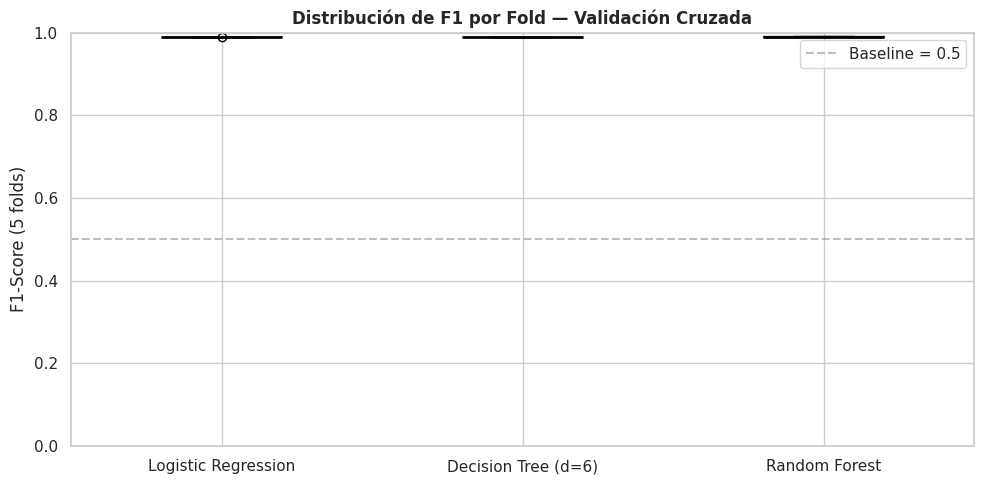

In [29]:
# Comparación visual: score por fold para cada modelo
fig, ax = plt.subplots(figsize=(10, 5))

posiciones = np.arange(len(modelos_cv))
ancho = 0.25
colores_cv = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (nombre, modelo) in enumerate(modelos_cv.items()):
    scores = cross_val_score(modelo, X_train_c_sc, y_train_c,
                             cv=skf, scoring='f1', n_jobs=-1)
    # Boxplot por modelo
    bp = ax.boxplot(scores, positions=[i], widths=0.4,
                    patch_artist=True,
                    boxprops=dict(facecolor=colores_cv[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))

ax.set_xticks(range(len(modelos_cv)))
ax.set_xticklabels(modelos_cv.keys(), fontsize=11)
ax.set_ylabel('F1-Score (5 folds)', fontsize=12)
ax.set_title('Distribución de F1 por Fold — Validación Cruzada', fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline = 0.5')
ax.legend()
plt.tight_layout()
plt.show()


---
## 4. Ajuste de Hiperparámetros — GridSearchCV

Un modelo con sus **hiperparámetros por defecto** raramente es el óptimo. GridSearchCV explora sistemáticamente una cuadrícula de valores y selecciona la combinación con mejor desempeño **usando validación cruzada interna**.

>  **Error común:** Evaluar el GridSearchCV sobre el test set y luego reportar ese resultado como si fuera independiente. El proceso correcto:
> 1. GridSearchCV solo sobre **X_train** (con CV interna)
> 2. Evaluar el mejor modelo encontrado sobre **X_test** (una sola vez)


In [30]:
from sklearn.model_selection import GridSearchCV

# ── Grilla de hiperparámetros para Random Forest ──────────────────────────────
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth'   : [6, 10, None],
    'min_samples_leaf': [10, 30],
}

# Usamos F1 como métrica de búsqueda porque las clases tienen cierto desbalance
gs_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

gs_rf.fit(X_train_c_sc, y_train_c)

print('=== GridSearchCV — Random Forest ===')
print(f'  Mejor combinación: {gs_rf.best_params_}')
print(f'  Mejor F1 (CV)    : {gs_rf.best_score_:.4f}')


=== GridSearchCV — Random Forest ===
  Mejor combinación: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}
  Mejor F1 (CV)    : 0.9903


In [31]:
# Evaluar el mejor modelo sobre el test set (¡solo una vez!)
best_rf = gs_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_c_sc)
y_prob_best_rf = best_rf.predict_proba(X_test_c_sc)[:, 1]

print('=== Mejor Random Forest — Evaluación final en Test ===')
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_best_rf):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_best_rf):.4f}')
print(f'  Recall    : {recall_score(y_test_c, y_pred_best_rf):.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_best_rf):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_best_rf):.4f}')


=== Mejor Random Forest — Evaluación final en Test ===
  Accuracy  : 0.9811
  Precision : 0.9811
  Recall    : 1.0000
  F1-Score  : 0.9905
  AUC-ROC   : 0.9855


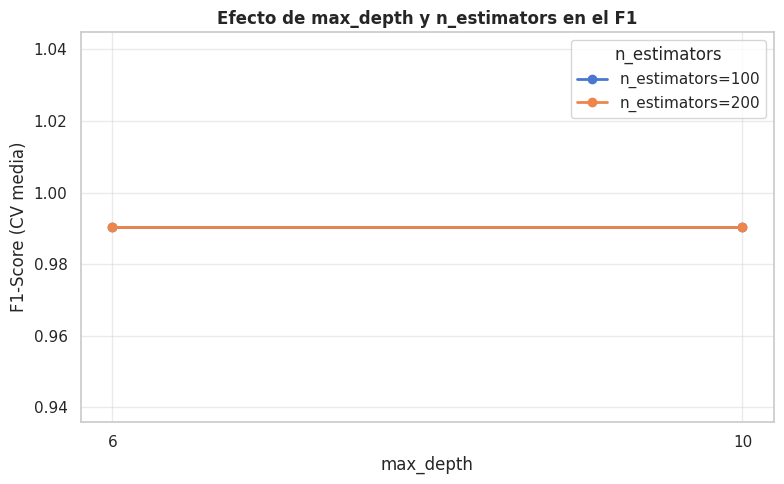

In [32]:
# Visualización del impacto de max_depth en el F1
cv_results = pd.DataFrame(gs_rf.cv_results_)

pivot = cv_results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

fig, ax = plt.subplots(figsize=(8, 5))
for col in pivot.columns:
    # Reemplazar None con string legible para el gráfico
    y_vals = pivot[col].values
    x_vals = [str(x) if x is not None else 'Sin límite' for x in pivot.index]
    ax.plot(x_vals, y_vals, marker='o', linewidth=2, label=f'n_estimators={col}')

ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('F1-Score (CV media)', fontsize=12)
ax.set_title('Efecto de max_depth y n_estimators en el F1', fontweight='bold')
ax.legend(title='n_estimators')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


---
## 5. Problema de Regresión: Predicción del Salario Total

**Variable objetivo:** `SalarioTotal` (salario total en USD)  
**Tipo:** Regresión (variable continua)

### 5.1 Métricas de Regresión

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **MAE** | mean(|y - ŷ|) | Error promedio en la misma unidad que y |
| **MSE** | mean((y - ŷ)²) | Penaliza errores grandes más que MAE |
| **RMSE** | √MSE | Interpretable en la misma unidad que y |
| **R²** | 1 - SS_res/SS_tot | % de varianza explicada (1 = perfecto, 0 = media) |

Un R² de 0.85 significa que el modelo explica el 85% de la variabilidad del salario.

### 5.2 Regresión Lineal — Línea base


In [33]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Imputar NaN residuales en regresión (fit solo en train)
imputer_r = SimpleImputer(strategy='median')
X_train_r_sc = imputer_r.fit_transform(X_train_r_sc)
X_test_r_sc  = imputer_r.transform(X_test_r_sc)

def metricas_regresion(nombre, y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_real, y_pred)
    print(f'=== {nombre} ===')
    print(f'  MAE  : ${mae:>12,.2f}')
    print(f'  MSE  : ${mse:>12,.2f}')
    print(f'  RMSE : ${rmse:>12,.2f}')
    print(f'  R²   : {r2:>13.4f}')
    print()
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

resultados_reg = []

# Regresión Lineal
lr_reg = LinearRegression()
lr_reg.fit(X_train_r_sc, y_train_r)
y_pred_lr_reg = lr_reg.predict(X_test_r_sc)
resultados_reg.append(metricas_regresion('Regresión Lineal', y_test_r, y_pred_lr_reg))

=== Regresión Lineal ===
  MAE  : $      551.15
  MSE  : $  523,861.66
  RMSE : $      723.78
  R²   :        0.7028



### 5.3 Ridge Regression

Ridge agrega un término de **regularización L2** que penaliza coeficientes grandes:

`Función de costo = MSE + λ · Σ(βᵢ²)`

El hiperparámetro `alpha` (= λ) controla la fuerza de la regularización. Es útil cuando hay **multicolinealidad** entre features (como en nuestro caso, donde SalarioBase y SalarioTotalConBeneficios estaban muy correlacionados).


In [34]:
# Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_r_sc, y_train_r)
y_pred_ridge = ridge.predict(X_test_r_sc)
resultados_reg.append(metricas_regresion('Ridge (alpha=10)', y_test_r, y_pred_ridge))


=== Ridge (alpha=10) ===
  MAE  : $      551.25
  MSE  : $  523,817.82
  RMSE : $      723.75
  R²   :        0.7028



### 5.4 Decision Tree Regressor y Random Forest Regressor


In [35]:
# Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=8, min_samples_leaf=30, random_state=42)
dt_reg.fit(X_train_r_sc, y_train_r)
y_pred_dt_reg = dt_reg.predict(X_test_r_sc)
resultados_reg.append(metricas_regresion('Decision Tree Regressor (d=8)', y_test_r, y_pred_dt_reg))

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=12,
                                min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r_sc, y_train_r)
y_pred_rf_reg = rf_reg.predict(X_test_r_sc)
resultados_reg.append(metricas_regresion('Random Forest Regressor', y_test_r, y_pred_rf_reg))


=== Decision Tree Regressor (d=8) ===
  MAE  : $      196.05
  MSE  : $   93,666.45
  RMSE : $      306.05
  R²   :        0.9469

=== Random Forest Regressor ===
  MAE  : $       31.50
  MSE  : $    3,037.52
  RMSE : $       55.11
  R²   :        0.9983



In [36]:
# ── Tabla comparativa — Regresión ──────────────────────────────────────────────
df_reg = pd.DataFrame(resultados_reg).set_index('Modelo')
print('=== Comparación de Modelos de Regresión ===')
print(df_reg.round(4).to_string())
print()
print(f'   Mejor R²   : {df_reg["R²"].idxmax()}')
print(f'   Menor RMSE : {df_reg["RMSE"].idxmin()}')


=== Comparación de Modelos de Regresión ===
                                   MAE     RMSE     R²
Modelo                                                
Regresión Lineal              551.1487 723.7829 0.7028
Ridge (alpha=10)              551.2487 723.7526 0.7028
Decision Tree Regressor (d=8) 196.0456 306.0497 0.9469
Random Forest Regressor        31.5005  55.1137 0.9983

   Mejor R²   : Random Forest Regressor
   Menor RMSE : Random Forest Regressor


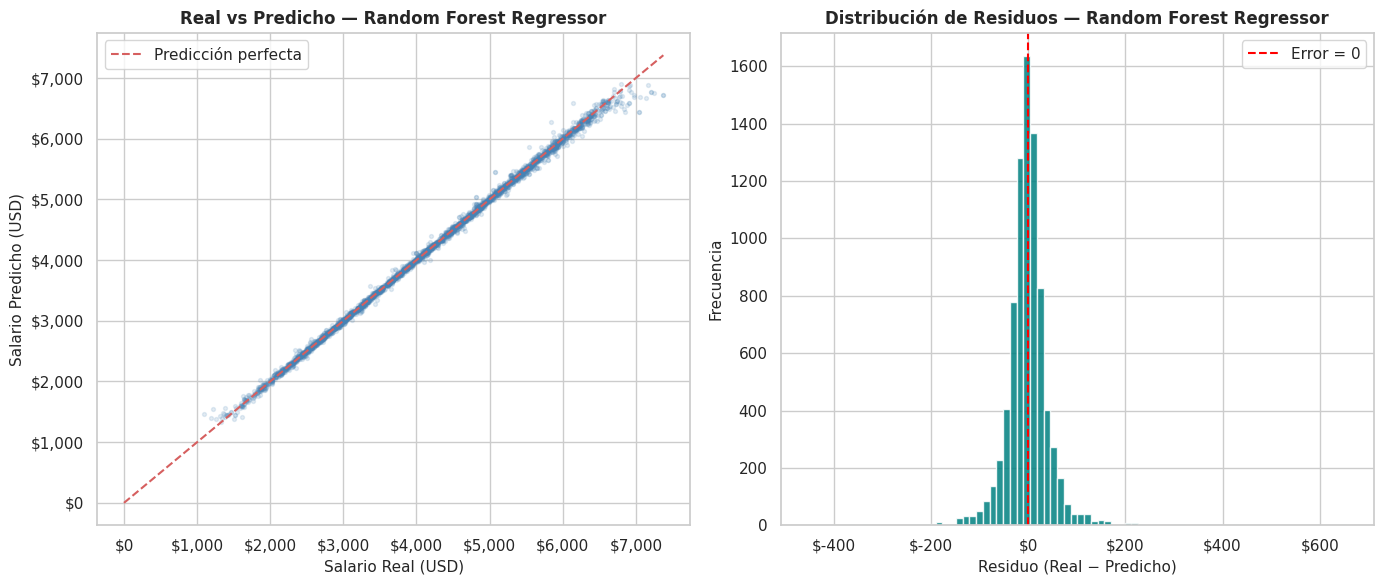

Interpretación de residuos:
  Media de residuos    : $-0.58  (idealmente ≈ 0)
  Std de residuos      : $55.11
  Residuos > $10,000   : 0 casos


In [37]:
# ── Visualización: Real vs Predicho ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: scatter real vs predicho (Random Forest)
sample_idx_plot = np.random.choice(len(y_test_r), size=3000, replace=False)
y_real_s  = y_test_r.iloc[sample_idx_plot]
y_pred_s  = y_pred_rf_reg[sample_idx_plot]

axes[0].scatter(y_real_s, y_pred_s, alpha=0.15, s=8, color='steelblue')
lim = max(y_real_s.max(), y_pred_s.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Salario Real (USD)', fontsize=11)
axes[0].set_ylabel('Salario Predicho (USD)', fontsize=11)
axes[0].set_title('Real vs Predicho — Random Forest Regressor', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# Panel derecho: distribución de residuos
residuos = y_test_r.values - y_pred_rf_reg
axes[1].hist(residuos, bins=80, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Error = 0')
axes[1].set_xlabel('Residuo (Real − Predicho)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de Residuos — Random Forest Regressor', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.show()

print('Interpretación de residuos:')
print(f'  Media de residuos    : ${residuos.mean():,.2f}  (idealmente ≈ 0)')
print(f'  Std de residuos      : ${residuos.std():,.2f}')
print(f'  Residuos > $10,000   : {(np.abs(residuos) > 10000).sum():,} casos')


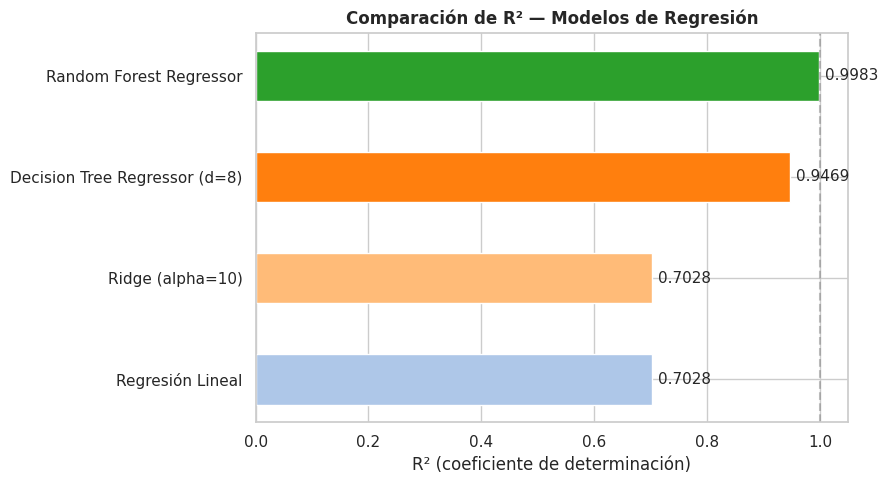

In [38]:
# ── Comparación visual de R² por modelo ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colores_reg = ['#aec7e8', '#ffbb78', '#ff7f0e', '#2ca02c']
modelos_nombres = df_reg.index.tolist()
r2_vals = df_reg['R²'].values

bars = ax.barh(modelos_nombres, r2_vals, color=colores_reg, edgecolor='white', height=0.5)
ax.set_xlabel('R² (coeficiente de determinación)', fontsize=12)
ax.set_title('Comparación de R² — Modelos de Regresión', fontweight='bold')
ax.set_xlim(0, 1.05)

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11)

ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---
## 6. Curvas de Aprendizaje

Las curvas de aprendizaje muestran cómo evoluciona el desempeño del modelo al **incrementar el tamaño del conjunto de entrenamiento**. Son la herramienta clave para diagnosticar:

| Patrón | Diagnóstico | Solución |
|--------|------------|----------|
| Train alto, Test bajo, gap grande | **Overfitting** (alta varianza) | Más datos, regularización, reducir complejidad |
| Train bajo, Test bajo, ambos convergen pronto | **Underfitting** (alto sesgo) | Modelo más complejo, más features |
| Train y Test convergen hacia arriba | Modelo correcto, puede mejorar con más datos | Recolectar más datos |


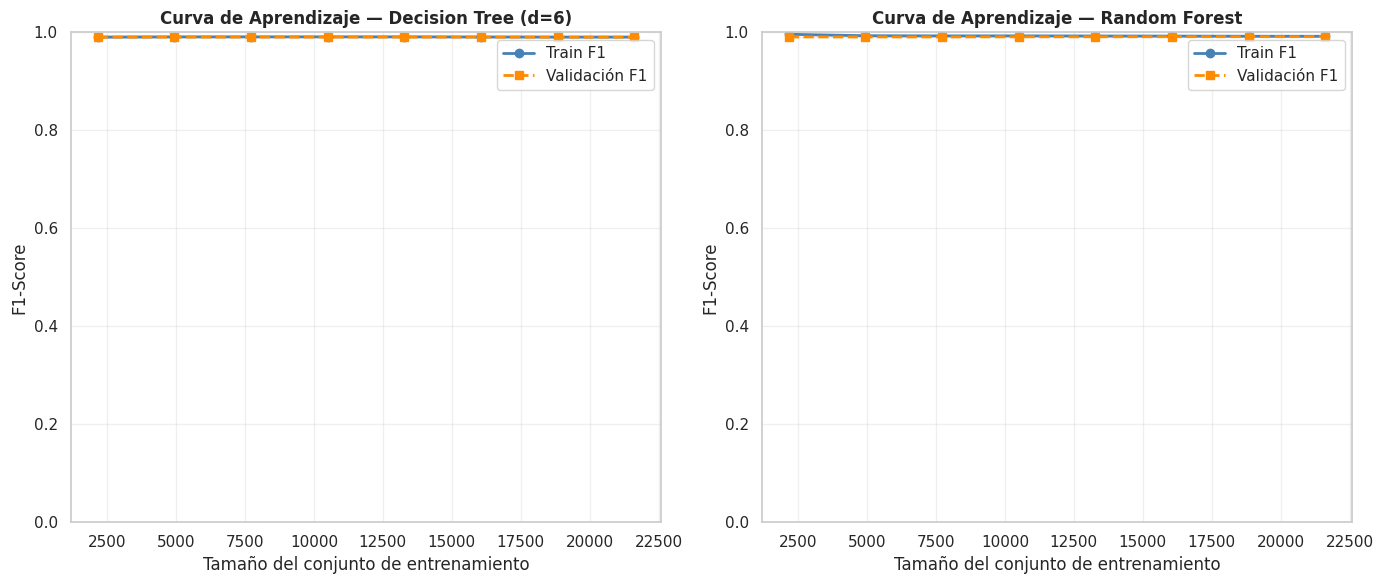

In [39]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

modelos_lc = {
    'Decision Tree (d=6)':  DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, max_depth=10,
                                                    random_state=42, n_jobs=-1),
}

for ax, (nombre, modelo) in zip(axes, modelos_lc.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train_c_sc, y_train_c,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1',
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train F1', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')

    ax.plot(train_sizes, val_mean, 's--', color='darkorange', label='Validación F1', linewidth=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='darkorange')

    ax.set_title(f'Curva de Aprendizaje — {nombre}', fontweight='bold')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('F1-Score')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. Resumen del Pipeline Completo

### 7.1 Resultados consolidados


In [40]:
# ── Resumen ejecutivo ──────────────────────────────────────────────────────────
print('='*65)
print('  RESUMEN EJECUTIVO — SEMANA 2')
print('='*65)

print()
print('── CLASIFICACIÓN: ¿Recibe overtime? ──')
print(f'  Mejor modelo (F1)   : {df_comp["F1-Score"].idxmax()}')
print(f'  Mejor F1            : {df_comp["F1-Score"].max():.4f}')
print(f'  Mejor AUC-ROC       : {df_comp["AUC-ROC"].max():.4f}')

print()
print('── REGRESIÓN: ¿Cuánto gana? ──')
print(f'  Mejor modelo (R²)   : {df_reg["R²"].idxmax()}')
print(f'  Mejor R²            : {df_reg["R²"].max():.4f}')
print(f'  Mejor RMSE          : ${df_reg["RMSE"].min():,.2f}')

print()
print('='*65)
print('  LECCIONES CLAVE DE ESTA SEMANA')
print('='*65)
lecciones = [
    ('1', 'Baseline primero', 'Siempre empieza con el modelo más simple (LR, LinReg)'),
    ('2', 'Overfitting es real', 'Un árbol sin poda memoriza; compara siempre train vs test'),
    ('3', 'CV es obligatoria', 'Un único split puede engañar; usa k-fold para estimar bien'),
    ('4', 'Métrica ≠ accuracy', 'Con desbalance de clases, prefiere F1 y AUC-ROC'),
    ('5', 'GridSearch en train', 'Nunca toques el test set durante la búsqueda de hiperparáms'),
    ('6', 'Residuos importan', 'Analizar el error en regresión revela sesgos sistemáticos'),
]
for num, titulo, desc in lecciones:
    print(f'  {num}. {titulo:<20}: {desc}')
print('='*65)


  RESUMEN EJECUTIVO — SEMANA 2

── CLASIFICACIÓN: ¿Recibe overtime? ──
  Mejor modelo (F1)   : Decision Tree (d=6)
  Mejor F1            : 0.9904
  Mejor AUC-ROC       : 0.9924

── REGRESIÓN: ¿Cuánto gana? ──
  Mejor modelo (R²)   : Random Forest Regressor
  Mejor R²            : 0.9983
  Mejor RMSE          : $55.11

  LECCIONES CLAVE DE ESTA SEMANA
  1. Baseline primero    : Siempre empieza con el modelo más simple (LR, LinReg)
  2. Overfitting es real : Un árbol sin poda memoriza; compara siempre train vs test
  3. CV es obligatoria   : Un único split puede engañar; usa k-fold para estimar bien
  4. Métrica ≠ accuracy  : Con desbalance de clases, prefiere F1 y AUC-ROC
  5. GridSearch en train : Nunca toques el test set durante la búsqueda de hiperparáms
  6. Residuos importan   : Analizar el error en regresión revela sesgos sistemáticos


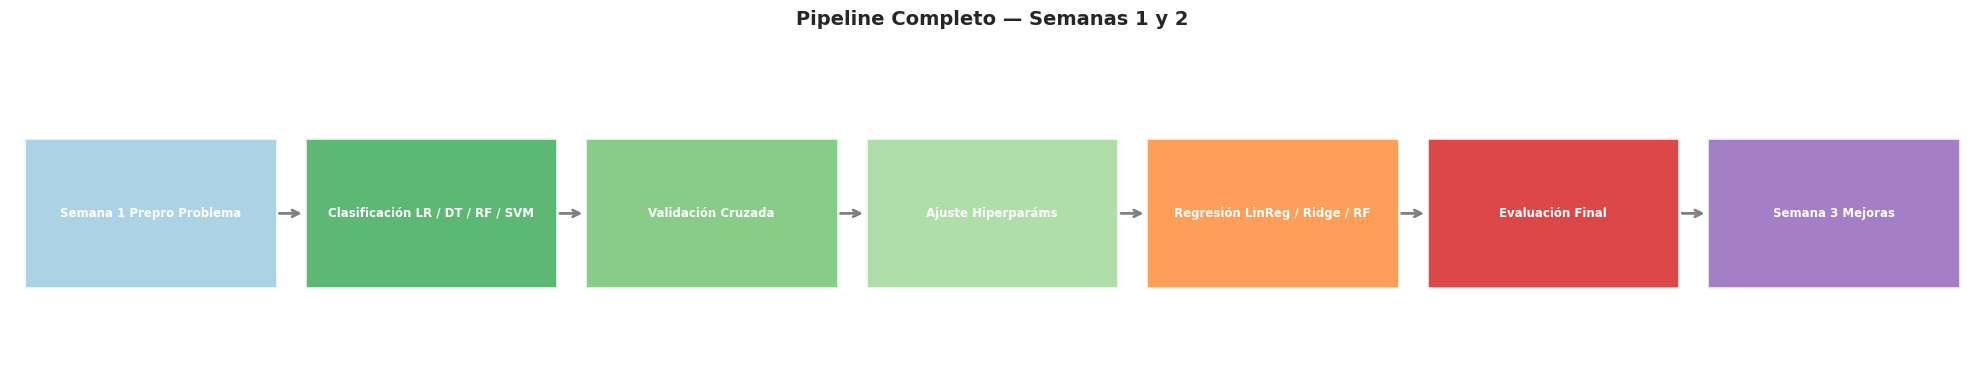

In [41]:
# ── Diagrama de flujo visual del pipeline completo ────────────────────────────
etapas_s2 = [
    ('Semana 1 Prepro Problema', '#9ecae1'),
    ('Clasificación LR / DT / RF / SVM', '#41ab5d'),
    ('Validación Cruzada', '#74c476'),
    ('Ajuste Hiperparáms', '#a1d99b'),
    ('Regresión LinReg / Ridge / RF', '#fd8d3c'),
    ('Evaluación Final', '#d62728'),
    ('Semana 3 Mejoras', '#9467bd'),
]

fig, ax = plt.subplots(figsize=(20, 4))
ax.set_xlim(0, len(etapas_s2))
ax.set_ylim(0, 3)
ax.axis('off')

for i, (titulo, color) in enumerate(etapas_s2):
    x = i + 0.5
    rect = plt.Rectangle((i + 0.05, 0.8), 0.9, 1.4,
                          facecolor=color, alpha=0.85, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, 1.5, titulo, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    if i < len(etapas_s2) - 1:
        ax.annotate('', xy=(i + 1.05, 1.5), xytext=(i + 0.95, 1.5),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_title('Pipeline Completo — Semanas 1 y 2', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
